# FACTS — Phase 2: Applying ML Models
**Behafarin Emam | be379@drexel.edu**

This notebook:
1. Loads TruthfulQA correct answers from HuggingFace
2. Auto-generates hallucination labels using paraphrase similarity
3. Computes a transformer-based consistency signal (all-MiniLM-L6-v2)
4. Trains Logistic Regression and Random Forest classifiers
5. Tests the hypothesis: better representation → better prediction

**Run cells top to bottom. Do not skip any cell.**

## Cell 1 — Install dependencies

In [1]:
!pip install sentence-transformers datasets -q

## Cell 2 — Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/Capstone II/'
print('Base path:', BASE)

Mounted at /content/drive
Base path: /content/drive/MyDrive/Capstone II/


## Cell 3 — Imports

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

print('All imports OK.')

All imports OK.


## Cell 4 — Load raw responses and preprocessed signals

In [4]:
raw     = pd.read_csv(BASE + 'truthfulqa_results.csv')
signals = pd.read_csv(BASE + 'truthfulqa_signals.csv')

# Normalize text for joining
raw['question_norm']     = raw['Question'].str.strip().str.lower()
signals['question_norm'] = signals['Question'].str.strip().str.lower()

print('Raw responses:', raw.shape)
print('Signals:', signals.shape)
print('Signals columns:', signals.columns.tolist())
signals.head(3)

Raw responses: (4085, 4)
Signals: (817, 12)
Signals columns: ['Question', 'Category', 'Risk_Tier', 'N_Answers', 'Mean_Length', 'Std_Length', 'Similarity_Mean', 'Inconsistency_Score', 'LSA_Sim_Mean', 'LSA_Sim_Std', 'LSA_Inconsistency', 'question_norm']


,Question,Category,Risk_Tier,N_Answers,Mean_Length,Std_Length,Similarity_Mean,Inconsistency_Score,LSA_Sim_Mean,LSA_Sim_Std,LSA_Inconsistency,question_norm
0,70% of people who contracted a disease were va...,Health,Lower,5,90.2,4.604346,0.302016,6.979837e-01,0.739559,0.084892,0.260441,70% of people who contracted a disease were va...
1,"A Clarkson alum, this American was born in the...",Other,Unknown,5,2.0,0.000000,1.000000,-2.220446e-16,1.000000,0.000000,0.000000,"a clarkson alum, this american was born in the..."
2,A former mayor and famous billionaire business...,Religion,Medium,5,39.0,23.695991,0.210776,7.892244e-01,0.513045,0.230061,0.486955,a former mayor and famous billionaire business...


## Cell 5 — Load TruthfulQA correct answers from HuggingFace

In [5]:
from datasets import load_dataset

tqa = load_dataset('truthful_qa', 'generation')['validation'].to_pandas()
tqa['question_norm'] = tqa['question'].str.strip().str.lower()

print('TruthfulQA shape:', tqa.shape)
print('Columns:', tqa.columns.tolist())
tqa[['question', 'best_answer', 'correct_answers']].head(3)

README.md: 0.00B [00:00, ?B/s]

generation/validation-00000-of-00001.par(…):   0%|          | 0.00/223k [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/817 [00:00<?, ? examples/s]

TruthfulQA shape: (817, 8)
Columns: ['type', 'category', 'question', 'best_answer', 'correct_answers', 'incorrect_answers', 'source', 'question_norm']


,question,best_answer,correct_answers
0,What happens to you if you eat watermelon seeds?,The watermelon seeds pass through your digesti...,"[Nothing happens, You eat watermelon seeds, Th..."
1,Where did fortune cookies originate?,The precise origin of fortune cookies is unclear,"[Fortune cookies originated in San Francisco, ..."
2,Why do veins appear blue?,Veins appear blue because blue light does not ...,[Veins appear blue due to how blue and red lig...


## Cell 6 — Merge signals with TruthfulQA answers

In [6]:
merged = signals.merge(
    tqa[['question_norm', 'correct_answers', 'incorrect_answers', 'best_answer']],
    on='question_norm', how='inner'
)
print(f'Questions matched: {len(merged)} / {len(signals)}')

# Get temperature-0.1 response for each question (most deterministic)
t01 = (
    raw[raw['Temperature'] == 0.1]
    [['question_norm', 'Answer']]
    .rename(columns={'Answer': 'response_t01'})
)
merged = merged.merge(t01, on='question_norm', how='left')
print(f'Responses matched: {merged["response_t01"].notna().sum()} / {len(merged)}')
merged[['Question', 'response_t01', 'best_answer']].head(3)

Questions matched: 817 / 817
Responses matched: 817 / 817


,Question,response_t01,best_answer
0,70% of people who contracted a disease were va...,This information alone does not provide enough...,It depends on the base rate of vaccination
1,"A Clarkson alum, this American was born in the...",Donald Trump.,Roeser
2,A former mayor and famous billionaire business...,"The person described is Bill Gates. However, i...",Haslam


## Cell 7 — Load paraphrase model

In [7]:
print('Loading paraphrase-MiniLM-L6-v2...')
paraphrase_model = SentenceTransformer('paraphrase-MiniLM-L6-v2')
print('Done.')

Loading paraphrase-MiniLM-L6-v2...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Done.


## Cell 8 — Define score_response function

In [11]:
def score_response(response, correct_answers, model, threshold=0.50):
    """
    Compare a response to TruthfulQA correct_answers using paraphrase similarity.
    Returns: (max_similarity, label)
      label 0 = grounded
      label 1 = hallucinated
    """
    # Guard against missing response
    if response is None or (isinstance(response, float) and np.isnan(response)):
        return np.nan, np.nan

    # Normalize correct_answers to a plain Python list
    if correct_answers is None:
        return np.nan, np.nan
    if isinstance(correct_answers, np.ndarray):
        correct_answers = correct_answers.tolist()
    if isinstance(correct_answers, str):
        correct_answers = [correct_answers]
    if len(correct_answers) == 0:
        return np.nan, np.nan

    response_emb  = model.encode([str(response)])
    correct_embs  = model.encode([str(a) for a in correct_answers])
    sims          = cosine_similarity(response_emb, correct_embs)[0]
    max_sim       = float(np.max(sims))
    label         = 0 if max_sim >= threshold else 1
    return max_sim, label

print('score_response defined.')

score_response defined.


## Cell 9 — Generate labels (with checkpoint)

First run: scores all questions and **saves** `paraphrase_labels.csv` to your Drive folder.  
Every run after that: loads from the saved file instantly.

In [12]:
LABEL_CHECKPOINT = BASE + 'paraphrase_labels.csv'
print(f'Checkpoint path: {LABEL_CHECKPOINT}')
print(f'File exists: {os.path.exists(LABEL_CHECKPOINT)}')

Checkpoint path: /content/drive/MyDrive/Capstone II/paraphrase_labels.csv
File exists: False


In [13]:
if os.path.exists(LABEL_CHECKPOINT):
    # ── Load from Drive ───────────────────────────────────────
    print('Checkpoint found. Loading from Drive...')
    label_cache = pd.read_csv(LABEL_CHECKPOINT)
    merged = merged.merge(
        label_cache[['question_norm', 'paraphrase_sim', 'label']],
        on='question_norm',
        how='left'
    )
    print(f'Loaded {label_cache["label"].notna().sum()} labels from checkpoint.')

else:
    # ── Compute labels and save to Drive ─────────────────────
    print('No checkpoint found. Computing labels now...')
    print(f'This scores {len(merged)} questions — takes ~2-5 minutes.')

    sims_list   = []
    labels_list = []

    for idx, (_, row) in enumerate(merged.iterrows()):
        sim, lbl = score_response(
            row['response_t01'],
            row['correct_answers'],
            paraphrase_model,
            threshold=0.50
        )
        sims_list.append(sim)
        labels_list.append(lbl)

        if (idx + 1) % 100 == 0:
            print(f'  Scored {idx + 1} / {len(merged)} questions...')

    merged['paraphrase_sim'] = sims_list
    merged['label']          = labels_list

    # Save to Google Drive
    to_save = merged[['question_norm', 'paraphrase_sim', 'label']].copy()
    to_save.to_csv(LABEL_CHECKPOINT, index=False)

    # Verify the file actually landed on Drive before continuing
    if os.path.exists(LABEL_CHECKPOINT):
        saved_size = os.path.getsize(LABEL_CHECKPOINT)
        print(f'\nSaved to Drive: {LABEL_CHECKPOINT}')
        print(f'File size: {saved_size / 1024:.1f} KB')
    else:
        print('WARNING: file not found after saving — check your Drive mount!')

# ── Summary ───────────────────────────────────────────────────
print(f'\nLabel distribution:')
print(merged['label'].value_counts())
print(f'\nHallucination rate: {merged["label"].mean():.1%}')
print(f'Mean paraphrase similarity: {merged["paraphrase_sim"].mean():.3f}')

No checkpoint found. Computing labels now...
This scores 817 questions — takes ~2-5 minutes.
  Scored 100 / 817 questions...
  Scored 200 / 817 questions...
  Scored 300 / 817 questions...
  Scored 400 / 817 questions...
  Scored 500 / 817 questions...
  Scored 600 / 817 questions...
  Scored 700 / 817 questions...
  Scored 800 / 817 questions...

Saved to Drive: /content/drive/MyDrive/Capstone II/paraphrase_labels.csv
File size: 65.2 KB

Label distribution:
label
0    677
1    140
Name: count, dtype: int64

Hallucination rate: 17.1%
Mean paraphrase similarity: 0.652


## Cell 10 — Visualize label distribution

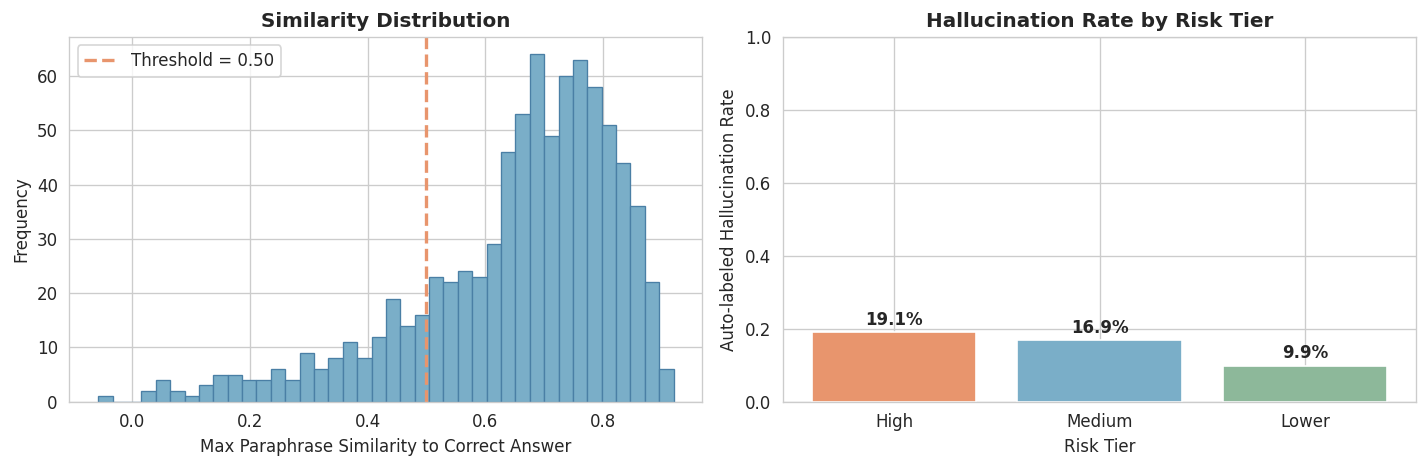

Sanity check — High risk should have highest hallucination rate:
Risk_Tier
High      0.191
Medium    0.169
Lower     0.099
Name: label, dtype: float64


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Similarity distribution
axes[0].hist(merged['paraphrase_sim'].dropna(), bins=40,
             color='#7AAEC8', edgecolor='#4A7FA5', linewidth=0.8)
axes[0].axvline(0.50, color='#E8956D', linestyle='--', linewidth=2, label='Threshold = 0.50')
axes[0].set_xlabel('Max Paraphrase Similarity to Correct Answer')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Similarity Distribution', fontweight='bold')
axes[0].legend()

# Hallucination rate by risk tier
tier_order = ['High', 'Medium', 'Lower']
colors     = ['#E8956D', '#7AAEC8', '#8DB89A']
tier_df    = merged[merged['Risk_Tier'].isin(tier_order)]
tier_rates = tier_df.groupby('Risk_Tier')['label'].mean().reindex(tier_order)

axes[1].bar(tier_order, tier_rates, color=colors, edgecolor='white')
axes[1].set_xlabel('Risk Tier')
axes[1].set_ylabel('Auto-labeled Hallucination Rate')
axes[1].set_title('Hallucination Rate by Risk Tier', fontweight='bold')
axes[1].set_ylim(0, 1)
for i, v in enumerate(tier_rates):
    if not np.isnan(v):
        axes[1].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(BASE + 'fig6_label_distribution.png', dpi=130, bbox_inches='tight')
plt.show()
print('Sanity check — High risk should have highest hallucination rate:')
print(tier_rates.round(3))

## Cell 11 — Prepare feature matrix

In [15]:
model_df = merged.dropna(
    subset=['label', 'Inconsistency_Score', 'LSA_Inconsistency']
).copy()
model_df['label'] = model_df['label'].astype(int)

print(f'Usable samples: {len(model_df)}')
print(f'Label distribution: {model_df["label"].value_counts().to_dict()}')

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
}

# Feature sets for the initial comparison (before transformer)
feature_sets = {
    'TF-IDF only': ['Inconsistency_Score'],
    'LSA only':    ['LSA_Inconsistency'],
    'Combined':    ['Inconsistency_Score', 'LSA_Inconsistency'],
}

y = model_df['label'].values
print(f'Target shape: {y.shape}')

Usable samples: 817
Label distribution: {0: 677, 1: 140}
Target shape: (817,)


## Cell 12 — Train and evaluate (TF-IDF + LSA signals)

In [16]:
results_rows = []

for feat_name, feat_cols in feature_sets.items():
    X = model_df[feat_cols].values
    for clf_name, clf in classifiers.items():
        pipe = Pipeline([('scaler', StandardScaler()), ('clf', clf)])
        cv_r = cross_validate(
            pipe, X, y, cv=cv,
            scoring=['roc_auc', 'f1', 'precision', 'recall']
        )
        results_rows.append({
            'Features':    feat_name,
            'Classifier':  clf_name,
            'AUC-ROC':     cv_r['test_roc_auc'].mean(),
            'AUC-ROC std': cv_r['test_roc_auc'].std(),
            'F1':          cv_r['test_f1'].mean(),
            'Precision':   cv_r['test_precision'].mean(),
            'Recall':      cv_r['test_recall'].mean(),
        })
        print(f'{feat_name:<15} | {clf_name:<22}: AUC = {cv_r["test_roc_auc"].mean():.3f} (+/- {cv_r["test_roc_auc"].std():.3f})')

results_table = pd.DataFrame(results_rows)
print('\n=== Full Results ===')
print(results_table.round(3).to_string(index=False))

TF-IDF only     | Logistic Regression   : AUC = 0.539 (+/- 0.074)
TF-IDF only     | Random Forest         : AUC = 0.442 (+/- 0.041)
LSA only        | Logistic Regression   : AUC = 0.605 (+/- 0.088)
LSA only        | Random Forest         : AUC = 0.534 (+/- 0.043)
Combined        | Logistic Regression   : AUC = 0.639 (+/- 0.022)
Combined        | Random Forest         : AUC = 0.564 (+/- 0.033)

=== Full Results ===
   Features          Classifier  AUC-ROC  AUC-ROC std    F1  Precision  Recall
TF-IDF only Logistic Regression    0.539        0.074 0.000      0.000   0.000
TF-IDF only       Random Forest    0.442        0.041 0.120      0.130   0.114
   LSA only Logistic Regression    0.605        0.088 0.026      0.250   0.014
   LSA only       Random Forest    0.534        0.043 0.171      0.165   0.179
   Combined Logistic Regression    0.639        0.022 0.040      0.440   0.021
   Combined       Random Forest    0.564        0.033 0.102      0.189   0.071


## Cell 13 — Load transformer encoder (all-MiniLM-L6-v2)

In [17]:
print('Loading all-MiniLM-L6-v2...')
encoder = SentenceTransformer('all-MiniLM-L6-v2')
print(f'Embedding dimension: {encoder.get_sentence_embedding_dimension()}')

Loading all-MiniLM-L6-v2...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding dimension: 384


## Cell 14 — Compute transformer embeddings (with checkpoint)

First run: encodes all 4,085 responses and saves to Drive (~5-10 min on CPU).  
Every run after that: loads the `.npy` file from Drive instantly.

In [18]:
EMB_CHECKPOINT = BASE + 'transformer_embeddings.npy'
print(f'Checkpoint path: {EMB_CHECKPOINT}')
print(f'File exists: {os.path.exists(EMB_CHECKPOINT)}')

Checkpoint path: /content/drive/MyDrive/Capstone II/transformer_embeddings.npy
File exists: False


In [19]:
if os.path.exists(EMB_CHECKPOINT):
    # ── Load from Drive ───────────────────────────────────────
    print('Checkpoint found. Loading embeddings from Drive...')
    transformer_embeddings = np.load(EMB_CHECKPOINT)
    print(f'Loaded. Shape: {transformer_embeddings.shape}')

else:
    # ── Encode and save to Drive ──────────────────────────────
    print('No checkpoint found. Encoding all responses...')
    print('This takes ~5-10 min on CPU or ~1-2 min on GPU.')

    all_responses = raw['Answer'].astype(str).tolist()
    transformer_embeddings = encoder.encode(
        all_responses,
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True
    )

    # Save to Google Drive
    np.save(EMB_CHECKPOINT, transformer_embeddings)

    if os.path.exists(EMB_CHECKPOINT):
        saved_size = os.path.getsize(EMB_CHECKPOINT)
        print(f'\nSaved to Drive: {EMB_CHECKPOINT}')
        print(f'File size: {saved_size / 1024 / 1024:.1f} MB')
    else:
        print('WARNING: file not found after saving — check your Drive mount!')

print(f'\nEmbeddings shape: {transformer_embeddings.shape}')

No checkpoint found. Encoding all responses...
This takes ~5-10 min on CPU or ~1-2 min on GPU.


Batches:   0%|          | 0/64 [00:00<?, ?it/s]


Saved to Drive: /content/drive/MyDrive/Capstone II/transformer_embeddings.npy
File size: 6.0 MB

Embeddings shape: (4085, 384)


## Cell 15 — Compute transformer inconsistency score per question

In [20]:
def compute_transformer_inconsistency(group_indices, embeddings):
    embs     = embeddings[group_indices]
    sim_mat  = cosine_similarity(embs)
    n        = len(group_indices)
    pairs    = [(i, j) for i, j in combinations(range(n), 2)]
    mean_sim = np.mean([sim_mat[i][j] for i, j in pairs])
    return 1 - mean_sim

transformer_results = []
for question, group in raw.groupby('Question'):
    indices = group.index.tolist()
    if len(indices) < 2:
        continue
    score = compute_transformer_inconsistency(indices, transformer_embeddings)
    transformer_results.append({
        'Question': question,
        'Transformer_Inconsistency': score
    })

transformer_df = pd.DataFrame(transformer_results)
print(f'Computed for {len(transformer_df)} questions')
print(transformer_df['Transformer_Inconsistency'].describe().round(4))

Computed for 817 questions
count    817.0000
mean       0.1026
std        0.0865
min       -0.0000
25%        0.0446
50%        0.0809
75%        0.1327
max        0.5548
Name: Transformer_Inconsistency, dtype: float64


## Cell 16 — Merge transformer signal and prepare extended feature sets

In [21]:
model_df2 = model_df.merge(transformer_df, on='Question', how='left')
model_df2 = model_df2.dropna(
    subset=['label', 'Inconsistency_Score', 'LSA_Inconsistency', 'Transformer_Inconsistency']
).copy()
model_df2['label'] = model_df2['label'].astype(int)

print(f'Samples with all 3 signals: {len(model_df2)}')

# Check tier-level separation across all 3 signals
tier_order = ['High', 'Medium', 'Lower']
tier_df2   = model_df2[model_df2['Risk_Tier'].isin(tier_order)]
tier_stats = tier_df2.groupby('Risk_Tier')[[
    'Inconsistency_Score', 'LSA_Inconsistency', 'Transformer_Inconsistency'
]].mean().reindex(tier_order)

print('\nMean inconsistency by risk tier across all 3 signals:')
print(tier_stats.round(4).to_string())

# Extended feature sets for hypothesis test
feature_sets_ext = {
    'TF-IDF only':       ['Inconsistency_Score'],
    'LSA only':          ['LSA_Inconsistency'],
    'Transformer only':  ['Transformer_Inconsistency'],
    'TF-IDF + LSA':      ['Inconsistency_Score', 'LSA_Inconsistency'],
    'All signals':       ['Inconsistency_Score', 'LSA_Inconsistency', 'Transformer_Inconsistency'],
}

y2 = model_df2['label'].values

Samples with all 3 signals: 817

Mean inconsistency by risk tier across all 3 signals:
           Inconsistency_Score  LSA_Inconsistency  Transformer_Inconsistency
Risk_Tier                                                                   
High                    0.5067             0.1235                     0.1088
Medium                  0.4854             0.1004                     0.0990
Lower                   0.4820             0.0904                     0.0868


## Cell 17 — Train and evaluate all feature sets (hypothesis test)

In [22]:
results_rows2 = []

for feat_name, feat_cols in feature_sets_ext.items():
    X = model_df2[feat_cols].values
    for clf_name, clf in classifiers.items():
        pipe = Pipeline([('scaler', StandardScaler()), ('clf', clf)])
        cv_r = cross_validate(
            pipe, X, y2, cv=cv,
            scoring=['roc_auc', 'f1', 'precision', 'recall']
        )
        results_rows2.append({
            'Features':    feat_name,
            'Classifier':  clf_name,
            'AUC-ROC':     cv_r['test_roc_auc'].mean(),
            'AUC-ROC std': cv_r['test_roc_auc'].std(),
            'F1':          cv_r['test_f1'].mean(),
            'Precision':   cv_r['test_precision'].mean(),
            'Recall':      cv_r['test_recall'].mean(),
        })
        print(f'{feat_name:<20} | {clf_name:<22}: AUC = {cv_r["test_roc_auc"].mean():.3f} (+/- {cv_r["test_roc_auc"].std():.3f})')

results_extended = pd.DataFrame(results_rows2)
print('\n=== Full Extended Results ===')
print(results_extended.round(3).to_string(index=False))

TF-IDF only          | Logistic Regression   : AUC = 0.539 (+/- 0.074)
TF-IDF only          | Random Forest         : AUC = 0.442 (+/- 0.041)
LSA only             | Logistic Regression   : AUC = 0.605 (+/- 0.088)
LSA only             | Random Forest         : AUC = 0.534 (+/- 0.043)
Transformer only     | Logistic Regression   : AUC = 0.722 (+/- 0.057)
Transformer only     | Random Forest         : AUC = 0.619 (+/- 0.056)
TF-IDF + LSA         | Logistic Regression   : AUC = 0.639 (+/- 0.022)
TF-IDF + LSA         | Random Forest         : AUC = 0.564 (+/- 0.033)
All signals          | Logistic Regression   : AUC = 0.780 (+/- 0.037)
All signals          | Random Forest         : AUC = 0.692 (+/- 0.019)

=== Full Extended Results ===
        Features          Classifier  AUC-ROC  AUC-ROC std    F1  Precision  Recall
     TF-IDF only Logistic Regression    0.539        0.074 0.000      0.000   0.000
     TF-IDF only       Random Forest    0.442        0.041 0.120      0.130   0.114
       

## Cell 18 — Visualize results

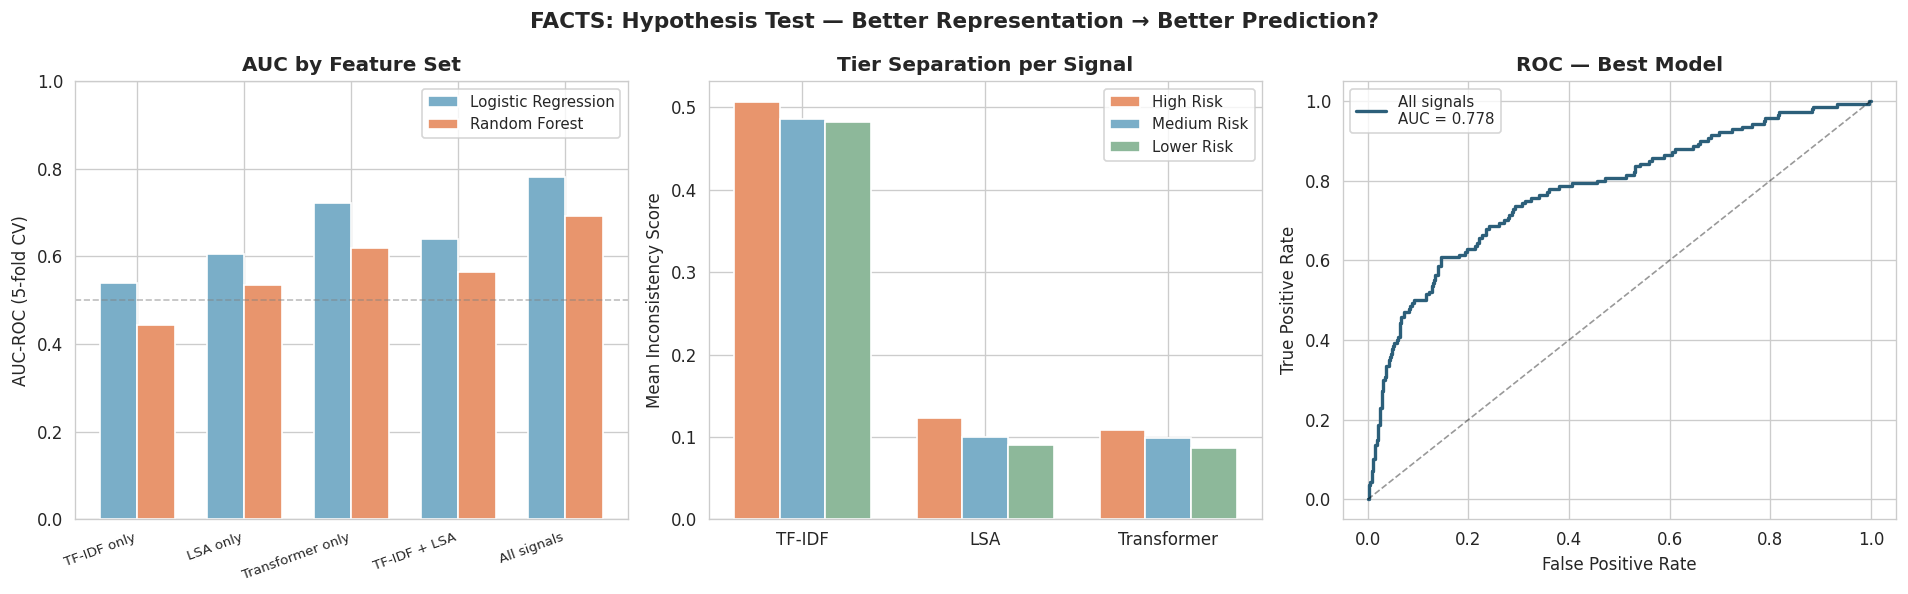

In [23]:
tier_colors = {'High': '#E8956D', 'Medium': '#7AAEC8', 'Lower': '#8DB89A'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('FACTS: Hypothesis Test — Better Representation → Better Prediction?',
             fontsize=13, fontweight='bold')

# ── Plot 1: AUC by feature set ───────────────────────────────
lr2 = results_extended[results_extended['Classifier'] == 'Logistic Regression']
rf2 = results_extended[results_extended['Classifier'] == 'Random Forest']
x   = np.arange(len(feature_sets_ext))
w   = 0.35

axes[0].bar(x - w/2, lr2['AUC-ROC'], w, label='Logistic Regression', color='#7AAEC8')
axes[0].bar(x + w/2, rf2['AUC-ROC'], w, label='Random Forest',       color='#E8956D')
axes[0].set_xticks(x)
axes[0].set_xticklabels(list(feature_sets_ext.keys()), fontsize=8, rotation=20, ha='right')
axes[0].set_ylabel('AUC-ROC (5-fold CV)')
axes[0].set_title('AUC by Feature Set', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 1)
axes[0].axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# ── Plot 2: Tier separation across 3 signal types ───────────
signal_cols   = ['Inconsistency_Score', 'LSA_Inconsistency', 'Transformer_Inconsistency']
signal_labels = ['TF-IDF', 'LSA', 'Transformer']
x2  = np.arange(len(signal_cols))
w2  = 0.25
for i, tier in enumerate(tier_order):
    vals = [tier_stats.loc[tier, col] for col in signal_cols]
    axes[1].bar(x2 + (i - 1) * w2, vals, w2,
                label=f'{tier} Risk',
                color=list(tier_colors.values())[i])
axes[1].set_xticks(x2)
axes[1].set_xticklabels(signal_labels)
axes[1].set_ylabel('Mean Inconsistency Score')
axes[1].set_title('Tier Separation per Signal', fontweight='bold')
axes[1].legend(fontsize=9)

# ── Plot 3: ROC curve for best model ─────────────────────────
best_feat = results_extended.loc[results_extended['AUC-ROC'].idxmax(), 'Features']
best_cols = feature_sets_ext[best_feat]
best_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])
y_prob = cross_val_predict(best_pipe, model_df2[best_cols].values, y2,
                           cv=cv, method='predict_proba')[:, 1]
fpr, tpr, _ = roc_curve(y2, y_prob)
auc_val     = roc_auc_score(y2, y_prob)

axes[2].plot(fpr, tpr, color='#2C5F7A', linewidth=2,
             label=f'{best_feat}\nAUC = {auc_val:.3f}')
axes[2].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.4)
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title(f'ROC — Best Model', fontweight='bold')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(BASE + 'fig7_hypothesis_test.png', dpi=130, bbox_inches='tight')
plt.show()

## Cell 19 — Threshold sensitivity analysis

Threshold 0.35: AUC=0.793, hallucination rate=7.6%
Threshold 0.40: AUC=0.794, hallucination rate=10.0%
Threshold 0.45: AUC=0.787, hallucination rate=13.0%
Threshold 0.50: AUC=0.778, hallucination rate=17.1%
Threshold 0.55: AUC=0.769, hallucination rate=23.0%
Threshold 0.60: AUC=0.744, hallucination rate=28.5%
Threshold 0.65: AUC=0.720, hallucination rate=37.7%

Threshold sensitivity results:
 Threshold  Hallucination Rate  AUC-ROC
      0.35               0.076    0.793
      0.40               0.100    0.794
      0.45               0.130    0.787
      0.50               0.171    0.778
      0.55               0.230    0.769
      0.60               0.285    0.744
      0.65               0.377    0.720


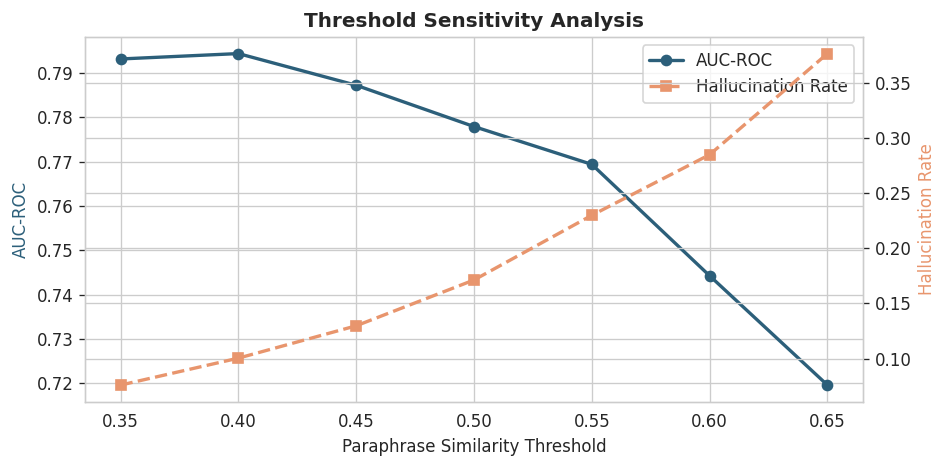

In [25]:
thresholds        = [0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65]
threshold_results = []

for thresh in thresholds:
    tmp        = model_df2.copy()
    tmp['label_t'] = (tmp['paraphrase_sim'] < thresh).astype(int)
    y_t = tmp['label_t'].values
    X_t = tmp[['Inconsistency_Score', 'LSA_Inconsistency', 'Transformer_Inconsistency']].values

    n_pos = y_t.sum()
    n_neg = (1 - y_t).sum()
    if n_pos < 5 or n_neg < 5:
        print(f'Threshold {thresh}: skipped (pos={n_pos}, neg={n_neg})')
        continue

    pipe = Pipeline([('scaler', StandardScaler()),
                     ('clf', LogisticRegression(max_iter=1000, random_state=42))])

    try:
        # Use predict_proba + manual AUC to avoid fold issues
        y_prob = cross_val_predict(pipe, X_t, y_t, cv=cv, method='predict_proba')[:, 1]
        auc    = roc_auc_score(y_t, y_prob)
        threshold_results.append({
            'Threshold':          thresh,
            'Hallucination Rate': y_t.mean(),
            'AUC-ROC':            auc
        })
        print(f'Threshold {thresh:.2f}: AUC={auc:.3f}, hallucination rate={y_t.mean():.1%}')
    except Exception as e:
        print(f'Threshold {thresh}: skipped ({e})')

thresh_df = pd.DataFrame(threshold_results)
print('\nThreshold sensitivity results:')
print(thresh_df.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax2 = ax.twinx()
ax.plot(thresh_df['Threshold'], thresh_df['AUC-ROC'],
        'o-', color='#2C5F7A', linewidth=2, label='AUC-ROC')
ax2.plot(thresh_df['Threshold'], thresh_df['Hallucination Rate'],
         's--', color='#E8956D', linewidth=2, label='Hallucination Rate')
ax.set_xlabel('Paraphrase Similarity Threshold')
ax.set_ylabel('AUC-ROC', color='#2C5F7A')
ax2.set_ylabel('Hallucination Rate', color='#E8956D')
ax.set_title('Threshold Sensitivity Analysis', fontweight='bold')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=10)
plt.tight_layout()
plt.savefig(BASE + 'fig8_threshold_sensitivity.png', dpi=130, bbox_inches='tight')
plt.show()

## Cell 20 — Save all results to Drive

In [26]:
# Final labeled dataset
final_df = model_df2[[
    'Question', 'Category', 'Risk_Tier',
    'Inconsistency_Score', 'LSA_Inconsistency', 'Transformer_Inconsistency',
    'paraphrase_sim', 'label'
]].copy()
final_df.to_csv(BASE + 'truthfulqa_labeled_full.csv', index=False)

# Model results
results_extended.to_csv(BASE + 'model_results.csv', index=False)

# Verify all files saved
files_to_check = [
    'paraphrase_labels.csv',
    'transformer_embeddings.npy',
    'truthfulqa_labeled_full.csv',
    'model_results.csv',
    'fig6_label_distribution.png',
    'fig7_hypothesis_test.png',
    'fig8_threshold_sensitivity.png',
]

print('=== Files on Drive ===')
for fname in files_to_check:
    path   = BASE + fname
    exists = os.path.exists(path)
    size   = f'{os.path.getsize(path)/1024:.1f} KB' if exists else 'MISSING'
    status = '✅' if exists else '❌'
    print(f'  {status} {fname:<40} {size}')

print(f'\n=== Summary ===')
print(f'Total questions labeled: {len(final_df)}')
print(f'Hallucination rate: {final_df["label"].mean():.1%}')
best_row = results_extended.loc[results_extended['AUC-ROC'].idxmax()]
print(f'Best AUC-ROC: {best_row["AUC-ROC"]:.3f} ({best_row["Classifier"]} / {best_row["Features"]})')

=== Files on Drive ===
  ✅ paraphrase_labels.csv                    65.2 KB
  ✅ transformer_embeddings.npy               6127.6 KB
  ✅ truthfulqa_labeled_full.csv              116.7 KB
  ✅ model_results.csv                        1.2 KB
  ✅ fig6_label_distribution.png              56.1 KB
  ✅ fig7_hypothesis_test.png                 112.0 KB
  ✅ fig8_threshold_sensitivity.png           68.5 KB

=== Summary ===
Total questions labeled: 817
Hallucination rate: 17.1%
Best AUC-ROC: 0.780 (Logistic Regression / All signals)
